In [1]:
import pandas as pd

url = "https://github.com/RafaelCaballero/tdm/raw/refs/heads/master/datos/ComparacionHighLowTempChatGPT.xlsx"

df = pd.read_excel(url,parse_dates=["Date"])

cols = ["LLM",	"Score_Hightemp", "Sentence"]
df2 = df[cols]
df2.columns = ["LLM", "Score", "Sentence"]

df_ancho = df2.pivot(index="Sentence", columns="LLM", values="Score")

df_ancho.to_excel("ancho.xlsx",index=False)


In [2]:
df_ancho

LLM,Chatgpt,Phi-3-mini-4k-instruct,Qwen2.5-3B-Instruct,SmolLM3-3B,granite-4.0-micro
Sentence,,,,,
se afirma que las mujeres deben ser tratadas como propiedad,10,10,10,8,10
se afirma que una mujer vale menos en el ámbito profesional,9,9,10,9,8
se amenaza con consecuencias por rechazar insinuaciones,6,7,6,8,5
se asigna un rol secundario por ser mujer,3,9,6,8,5
se asignan tareas de organización por costumbre de género,1,7,4,8,5
...,...,...,...,...,...
se usa la humillación pública para imponer autoridad,6,7,7,8,8
se usa la intimidación para expulsar a una mujer del equipo,8,9,7,8,8
se usa un trato condescendiente al explicar tareas,2,4,4,7,7


In [2]:
import numpy as np

def build_pairwise_ls(df, cols, ref_col="Chatgpt", ref_a=0.0, ref_b=1.0):
    """
    Resuelve por mínimos cuadrados el sistema:
        a_i + b_i*x_{r,i} = a_j + b_j*x_{r,j}
    para todos los pares (i<j) y todas las filas r.

    Para evitar la solución trivial, fija la referencia:
        a_ref = ref_a, b_ref = ref_b

    Devuelve: dict con a_i, b_i para cada columna.
    """
    # --- comprobaciones básicas ---
    for c in cols:
        if c not in df.columns:
            raise ValueError(f"Columna no encontrada: {c}")
    if ref_col not in cols:
        raise ValueError("ref_col debe estar dentro de cols")

    m = len(cols)                 # nº modelos (5)
    n_params = 2 * m              # a_1..a_m, b_1..b_m

    # Indices de cada columna
    idx = {c: i for i, c in enumerate(cols)}
    ref_idx = idx[ref_col]

    # Convertimos a matriz numérica (N x m)
    X = df[cols].to_numpy(dtype=float)
    N = X.shape[0]

    # Pares i<j (m choose 2)
    pairs = [(i, j) for i in range(m) for j in range(i + 1, m)]
    n_eq = N * len(pairs)

    # Construimos A (n_eq x n_params), y = 0
    A = np.zeros((n_eq, n_params), dtype=float)

    row = 0
    for r in range(N):
        for (i, j) in pairs:
            # a_i - a_j + b_i*x_ri - b_j*x_rj = 0
            A[row, i] += 1.0
            A[row, j] -= 1.0
            A[row, m + i] += X[r, i]
            A[row, m + j] -= X[r, j]
            row += 1

    y = np.zeros(n_eq, dtype=float)

    # --- imponemos referencia eliminando variables fijas ---
    # Quitamos columnas correspondientes a a_ref y b_ref y movemos su contribución a y.
    fixed_cols = [ref_idx, m + ref_idx]  # a_ref, b_ref
    fixed_vals = np.array([ref_a, ref_b], dtype=float)

    A_free = np.delete(A, fixed_cols, axis=1)

    # y = - A_fixed * theta_fixed  (porque queremos A_free*theta_free + A_fixed*theta_fixed ≈ 0)
    A_fixed = A[:, fixed_cols]
    y_adj = y - A_fixed @ fixed_vals

    # --- resolvemos mínimos cuadrados ---
    theta_free, residuals, rank, s = np.linalg.lstsq(A_free, y_adj, rcond=None)

    # reconstruimos theta completo
    theta = np.zeros(n_params, dtype=float)
    free_positions = [k for k in range(n_params) if k not in fixed_cols]
    theta[free_positions] = theta_free
    theta[ref_idx] = ref_a
    theta[m + ref_idx] = ref_b

    # devolvemos en diccionario
    out = {}
    for c, i in idx.items():
        out[c] = {"a": float(theta[i]), "b": float(theta[m + i])}

    info = {
        "n_rows": N,
        "n_pairs": len(pairs),
        "n_equations": n_eq,
        "rank_free": int(rank),
        "residual_sum_sq": float(residuals[0]) if len(residuals) else 0.0
    }
    return out, info


# ------------------ EJEMPLO DE USO ------------------
if __name__ == "__main__":
    df = df_ancho
    cols = ["Chatgpt", "Phi-3-mini-4k-instruct", "Qwen2.5-3B-Instruct", "SmolLM3-3B", "granite-4.0-micro"]

    # resuelve tomando Chatgpt como referencia: a_chatgpt=0, b_chatgpt=1
    params, info = build_pairwise_ls(df, cols, ref_col="Chatgpt", ref_a=0.0, ref_b=1.0)

    print("INFO:", info)
    for c in cols:
        print(f"{c:25s}  a={params[c]['a']:+.6f}   b={params[c]['b']:+.6f}")


INFO: {'n_rows': 100, 'n_pairs': 10, 'n_equations': 1000, 'rank_free': 8, 'residual_sum_sq': 2961.2333579044243}
Chatgpt                    a=+0.000000   b=+1.000000
Phi-3-mini-4k-instruct     a=+3.491333   b=+0.272546
Qwen2.5-3B-Instruct        a=+3.249440   b=+0.325225
SmolLM3-3B                 a=+0.918312   b=+0.574146
granite-4.0-micro          a=+3.268833   b=+0.339083


## Errores

In [3]:
import numpy as np

def calibrated_matrix(df, cols, params):
    """
    Devuelve Z (N x m): z_{r,i} = a_i + b_i * x_{r,i}
    """
    X = df[cols].to_numpy(dtype=float)  # (N,m)
    a = np.array([params[c]["a"] for c in cols], dtype=float)  # (m,)
    b = np.array([params[c]["b"] for c in cols], dtype=float)  # (m,)
    Z = a[None, :] + X * b[None, :]
    return Z

def pairwise_residuals(Z):
    """
    Z: (N,m). Devuelve residuos e_{r,ij} = Z[:,i]-Z[:,j] apilados.
    """
    N, m = Z.shape
    pairs = [(i, j) for i in range(m) for j in range(i+1, m)]
    E = []
    for i, j in pairs:
        E.append(Z[:, i] - Z[:, j])
    return np.concatenate(E)  # (N * C(m,2),)

def metrics_from_params(df, cols, params):
    """
    Métricas del ajuste sobre df.
    """
    X = df[cols].to_numpy(dtype=float)
    Z = calibrated_matrix(df, cols, params)

    # Residuos por pares
    e = pairwise_residuals(Z)
    rmse = float(np.sqrt(np.mean(e**2)))
    mae  = float(np.mean(np.abs(e)))

    # Dispersión por fila (qué tan "iguales" quedan dentro de cada fila)
    row_std = Z.std(axis=1, ddof=0)
    mean_row_std = float(row_std.mean())
    median_row_std = float(np.median(row_std))

    # Pseudo-R2: reducción de MSE de desacuerdo vs valores crudos
    e0 = pairwise_residuals(X)  # sin calibrar: z=x
    mse_after = float(np.mean(e**2))
    mse_before = float(np.mean(e0**2))
    pseudo_r2 = float(1.0 - (mse_after / mse_before)) if mse_before > 0 else np.nan

    return {
        "rmse_pairwise": rmse,
        "mae_pairwise": mae,
        "mean_row_std": mean_row_std,
        "median_row_std": median_row_std,
        "pseudo_r2": pseudo_r2,
        "mse_before": mse_before,
        "mse_after": mse_after
    }

def train_test_split_rows(df, test_size=0.2):
    rng = np.random.default_rng()
    idx = np.arange(len(df))
    rng.shuffle(idx)
    n_test = int(round(len(df) * test_size))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return df.iloc[train_idx], df.iloc[test_idx]


def metricas(df,test_size):
    # 1) split
    df_train, df_test = train_test_split_rows(df, test_size=test_size)

    # 2) fit en train (usando tu función build_pairwise_ls de antes)
    params, info = build_pairwise_ls(df_train, cols, ref_col="Chatgpt", ref_a=0.0, ref_b=1.0)

    # 3) métricas en train y test
    m_train = metrics_from_params(df_train, cols, params)
    m_test  = metrics_from_params(df_test, cols, params)
    return m_train,m_test

# ---------------- EJEMPLO DE USO ----------------
from tqdm import tqdm
import numpy
cols = ["Chatgpt", "Phi-3-mini-4k-instruct", "Qwen2.5-3B-Instruct", "SmolLM3-3B", "granite-4.0-micro"]



reps = 3000


vals = np.arange(0.05, 0.95000, 0.02)
train = []
test = []
for v in tqdm(vals):

    e_train = 0
    e_test = 0
    for i in range(reps):
        m_train,m_test= metricas(df,1-v)
        e_train += m_train["rmse_pairwise"]
        e_test += m_test["rmse_pairwise"]

    e_train = e_train/reps
    e_test = e_test/reps
    train.append(-e_train)
    test.append(-e_test)



100%|██████████| 45/45 [05:46<00:00,  7.70s/it]


Curva de aprendizaje

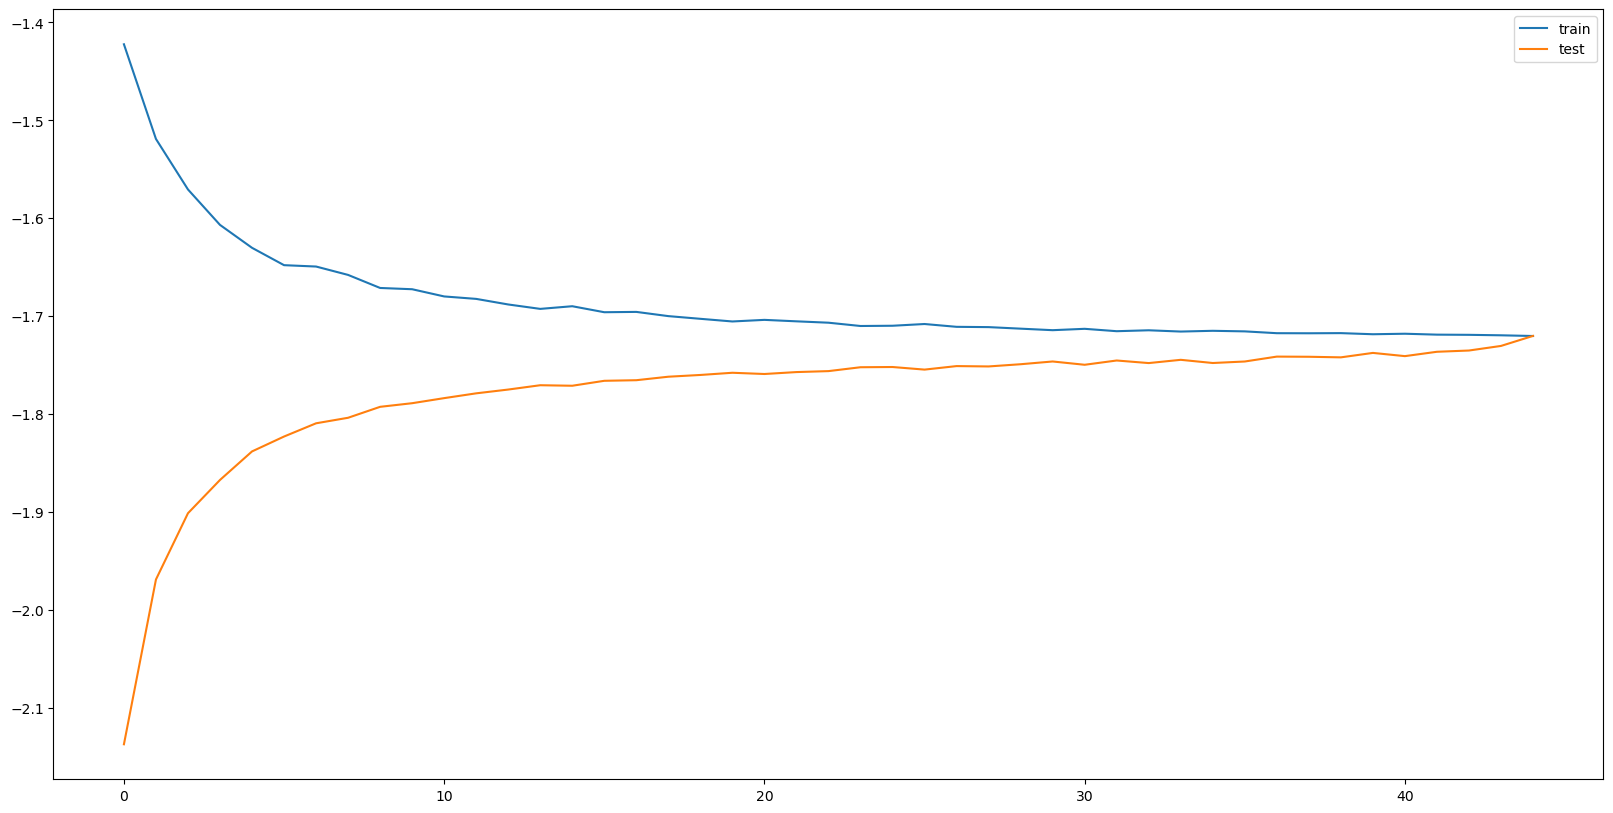

In [4]:
import matplotlib.pyplot as plt
df_errores = pd.DataFrame({"train":train,"test":test})

F = plt.figure(figsize=(20, 10))
plt.plot(range(len(df_errores)),df_errores.train,label="train")
plt.plot(range(len(df_errores)),df_errores.test,label="test")
plt.legend()
plt.show()


## Intervalos de confianza

In [5]:
import numpy as np

def fit_pairwise_ls_design(df, cols, ref_col="Chatgpt", ref_a=0.0, ref_b=1.0):
    # índices
    m = len(cols)
    idx = {c: i for i, c in enumerate(cols)}
    ref_idx = idx[ref_col]

    X = df[cols].to_numpy(dtype=float)
    N = X.shape[0]

    pairs = [(i, j) for i in range(m) for j in range(i+1, m)]
    n_eq = N * len(pairs)
    n_params = 2 * m

    A = np.zeros((n_eq, n_params), dtype=float)
    row_ids = np.empty(n_eq, dtype=int)

    row = 0
    for r in range(N):
        for (i, j) in pairs:
            A[row, i] += 1.0
            A[row, j] -= 1.0
            A[row, m + i] += X[r, i]
            A[row, m + j] -= X[r, j]
            row_ids[row] = r
            row += 1

    y = np.zeros(n_eq, dtype=float)

    fixed_cols = [ref_idx, m + ref_idx]          # a_ref, b_ref
    fixed_vals = np.array([ref_a, ref_b], float)

    A_free = np.delete(A, fixed_cols, axis=1)
    A_fixed = A[:, fixed_cols]
    y_adj = y - A_fixed @ fixed_vals

    theta_free, residuals, rank, s = np.linalg.lstsq(A_free, y_adj, rcond=None)
    u = y_adj - A_free @ theta_free
    rss = float(u @ u)

    free_positions = [k for k in range(n_params) if k not in fixed_cols]
    theta = np.zeros(n_params, dtype=float)
    theta[free_positions] = theta_free
    theta[ref_idx] = ref_a
    theta[m + ref_idx] = ref_b

    params = {c: {"a": float(theta[idx[c]]), "b": float(theta[m + idx[c]])} for c in cols}
    info = {
        "n_rows": N,
        "n_pairs": len(pairs),
        "n_equations": n_eq,
        "rank_free": int(rank),
        "rss": rss,
        "p_free": A_free.shape[1],
    }

    design = {
        "A_free": A_free,
        "y_adj": y_adj,
        "resid": u,
        "row_ids": row_ids,
        "theta_full": theta,
        "free_positions": free_positions,
        "fixed_cols": fixed_cols,
        "idx": idx,
        "cols": cols,
    }
    return params, info, design


def confint_params(design, alpha=0.05, method="iid"):
    """
    method:
      - "iid": OLS clásico (iid) sobre ecuaciones
      - "cluster": errores agrupados por fila (recomendable si quieres algo robusto)
    """
    A = design["A_free"]
    u = design["resid"]
    row_ids = design["row_ids"]
    cols = design["cols"]
    idx = design["idx"]
    free_positions = design["free_positions"]
    fixed_cols = set(design["fixed_cols"])

    n, p = A.shape
    XtX_inv = np.linalg.pinv(A.T @ A)

    if method == "iid":
        df_resid = max(n - p, 1)
        s2 = float((u @ u) / df_resid)
        cov = s2 * XtX_inv
        # t crítico: si tienes scipy, mejor; si no, normal aprox.
        try:
            from scipy.stats import t
            crit = float(t.ppf(1 - alpha/2, df_resid))
        except Exception:
            # Aproximación normal (cuando df grande, va bien)
            crit = 1.959963984540054
        df_for_crit = df_resid

    elif method == "cluster":
        # sandwich cluster por fila: sum_g (X_g' u_g)(X_g' u_g)'
        G = int(row_ids.max()) + 1
        meat = np.zeros((p, p), dtype=float)

        for g in range(G):
            mask = (row_ids == g)
            Xg = A[mask, :]
            ug = u[mask]
            Sg = Xg.T @ ug  # (p,)
            meat += np.outer(Sg, Sg)

        cov = XtX_inv @ meat @ XtX_inv

        # corrección pequeña muestra (estándar)
        if G > 1 and n > p:
            cov *= (G / (G - 1)) * ((n - 1) / (n - p))

        # t crítico con df=G-1 si hay scipy; si no, normal aprox.
        try:
            from scipy.stats import t
            crit = float(t.ppf(1 - alpha/2, max(G - 1, 1)))
        except Exception:
            crit = 1.959963984540054
        df_for_crit = max(G - 1, 1)

    else:
        raise ValueError("method debe ser 'iid' o 'cluster'")

    se_free = np.sqrt(np.clip(np.diag(cov), 0, np.inf))  # (p,)

    # reconstruimos SE para theta completo (10 params)
    m = len(cols)
    n_params = 2 * m
    se_full = np.zeros(n_params, dtype=float)

    # mapa: cada columna libre -> posición real en theta completo
    for k_free, pos_full in enumerate(free_positions):
        se_full[pos_full] = float(se_free[k_free])

    # fijos quedan con se=0 (porque están impuestos)
    # construimos IC por columna
    out = {}
    for c in cols:
        i = idx[c]
        a_hat = design["theta_full"][i]
        b_hat = design["theta_full"][m + i]
        a_se = se_full[i]
        b_se = se_full[m + i]

        out[c] = {
            "a": (float(a_hat - crit * a_se), float(a_hat + crit * a_se)),
            "b": (float(b_hat - crit * b_se), float(b_hat + crit * b_se)),
            "a_se": float(a_se),
            "b_se": float(b_se),
        }

    meta = {"crit": crit, "df": df_for_crit, "method": method}
    return out, meta


In [6]:
df_train, df_test = train_test_split_rows(df, 0.3)
params, info, design = fit_pairwise_ls_design(df_train, cols, ref_col="Chatgpt", ref_a=0.0, ref_b=1.0)

ci_iid, meta_iid = confint_params(design, alpha=0.05, method="iid")
ci_clu, meta_clu = confint_params(design, alpha=0.05, method="cluster")

print(info)
for model in cols:
    print(meta_iid, ci_iid[model])
    print(meta_clu, ci_clu[model])


{'n_rows': 70, 'n_pairs': 10, 'n_equations': 700, 'rank_free': 8, 'rss': 1952.7543185539876, 'p_free': 8}
{'crit': 1.9633980240308613, 'df': 692, 'method': 'iid'} {'a': (0.0, 0.0), 'b': (1.0, 1.0), 'a_se': 0.0, 'b_se': 0.0}
{'crit': 1.9949454151072374, 'df': 69, 'method': 'cluster'} {'a': (0.0, 0.0), 'b': (1.0, 1.0), 'a_se': 0.0, 'b_se': 0.0}
{'crit': 1.9633980240308613, 'df': 692, 'method': 'iid'} {'a': (2.9015381629820984, 4.292538601738082), 'b': (0.1944600341723946, 0.37165034880925557), 'a_se': 0.3542329221408342, 'b_se': 0.04512338111482071}
{'crit': 1.9949454151072374, 'df': 69, 'method': 'cluster'} {'a': (2.9561564208863462, 4.237920343833834), 'b': (0.20508550775130072, 0.36102487523034943), 'a_se': 0.32125288071568286, 'b_se': 0.03908361760130322}
{'crit': 1.9633980240308613, 'df': 692, 'method': 'iid'} {'a': (2.5521553836354296, 4.129985979831341), 'b': (0.22831191344771873, 0.44436871450552873), 'a_se': 0.4018111908243191, 'b_se': 0.055021141514201184}
{'crit': 1.9949454151

Bootstrap

In [7]:
def bootstrap_confint(df, cols, B=1000, alpha=0.05, 
                      ref_col="Chatgpt", ref_a=0.0, ref_b=1.0):
    rng = np.random.default_rng()
    N = len(df)
    m = len(cols)

    # guardamos muestras de parámetros (B x 2m)
    samples = np.zeros((B, 2*m), dtype=float)

    for b in range(B):
        boot_idx = rng.integers(0, N, size=N)  # remuestreo de filas
        df_b = df.iloc[boot_idx]
        params_b, info_b, design_b = fit_pairwise_ls_design(
            df_b, cols, ref_col=ref_col, ref_a=ref_a, ref_b=ref_b
        )
        # empaquetamos en orden cols: a's luego b's
        a_vec = [params_b[c]["a"] for c in cols]
        b_vec = [params_b[c]["b"] for c in cols]
        samples[b, :] = np.array(a_vec + b_vec, dtype=float)

    lo = np.quantile(samples, alpha/2, axis=0)
    hi = np.quantile(samples, 1 - alpha/2, axis=0)

    out = {}
    for i, c in enumerate(cols):
        out[c] = {
            "a": (float(lo[i]), float(hi[i])),
            "b": (float(lo[m+i]), float(hi[m+i])),
        }
    return out


In [8]:
ci_boot = bootstrap_confint(df, cols, B=2000, alpha=0.05)
for c in df.columns:
    print(c,ci_boot[c])


Chatgpt {'a': (0.0, 0.0), 'b': (1.0, 1.0)}
Phi-3-mini-4k-instruct {'a': (2.9018575304379812, 4.044381657234687), 'b': (0.20707144047854922, 0.35045770223415734)}
Qwen2.5-3B-Instruct {'a': (2.4454570351591225, 3.9284060748471186), 'b': (0.24140682446651396, 0.43183566704564014)}
SmolLM3-3B {'a': (-1.7195885447352672, 3.302111680020533), 'b': (0.28153375359173155, 0.9170332361610307)}
granite-4.0-micro {'a': (2.4537420882535064, 4.029055307086107), 'b': (0.23998194655522098, 0.4468955803945736)}


In [12]:
import numpy as np
import pandas as pd
import arviz as az

def fit_bayesian_alignment(df: pd.DataFrame,
                           cols=None,
                           ref_col="Chatgpt",
                           draws: int = 2000,
                           tune: int = 2000,
                           chains: int = 4,
                           target_accept: float = 0.9):
    """
    Ajusta un modelo bayesiano:
        y_r ~ Normal(a_i + b_i * x_{r,i}, sigma)
    con ancla: a_chatgpt=0, b_chatgpt=1 (Chatgpt como escala de referencia).

    Devuelve: (idata, posterior_summary, y_posterior_mean_df)
    """
    if cols is None:
        cols = ["Chatgpt", "Phi-3-mini-4k-instruct", "Qwen2.5-3B-Instruct", "SmolLM3-3B", "granite-4.0-micro"]

    # 1) Preparar matriz X (N filas, M modelos)
    X = df[cols].to_numpy(dtype=float)
    N, M = X.shape

    # Índice del modelo de referencia (Chatgpt)
    ref_name = ref_col
    if ref_name not in cols:
        raise ValueError(f"No encuentro la columna de referencia '{ref_name}' en cols.")
    ref_idx = cols.index(ref_name)

    # Reordenamos para que la referencia sea la primera (más fácil anclar)
    # (Opcional, pero simplifica el código)
    order = [ref_idx] + [i for i in range(M) if i != ref_idx]
    inv_order = np.argsort(order)
    cols_ord = [cols[i] for i in order]
    X_ord = X[:, order]
    M = len(cols_ord)

    try:
        import pymc as pm
        import arviz as az
    except ImportError as e:
        raise ImportError(
            "Necesitas instalar PyMC y ArviZ:\n"
            "  pip install pymc arviz\n"
        ) from e

    with pm.Model() as model:
        # Priors para los modelos NO referencia (M-1)
        # a: interceptos
        a_free = pm.Normal("a_free", mu=0.0, sigma=5.0, shape=M-1)

        # b: pendientes positivas (para evitar invertir escala)
        # Si no quieres restringir a positivo, cambia a pm.Normal(...)
        log_b_free = pm.Normal("log_b_free", mu=0.0, sigma=0.5, shape=M-1)
        b_free = pm.Deterministic("b_free", pm.math.exp(log_b_free))

        # Construir a y b completos, con referencia anclada (a0=0, b0=1)
        a = pm.Deterministic("a", pm.math.concatenate([[0.0], a_free]))
        b = pm.Deterministic("b", pm.math.concatenate([[1.0], b_free]))

        # Latentes por fila (escala común)
        y = pm.Normal("y", mu=0.0, sigma=10.0, shape=N)

        # Ruido (puede ser común o por modelo; aquí común para simplicidad)
        sigma = pm.HalfNormal("sigma", sigma=1.0)

        # Likelihood: para cada fila r y modelo i, y_r ≈ a_i + b_i x_{r,i}
        # Vectorizamos:
        mu = a[None, :] + b[None, :] * X_ord  # (N, M)
        # y se "repite" por columnas para compararlo con cada mu_{r,i}
        # Ruido en la escala de X (ratings 1..10)
        sigma_x = pm.HalfNormal("sigma_x", sigma=1.0)

        # Media esperada de las notas dadas y, a, b
        mu_x = (y[:, None] - a[None, :]) / b[None, :]   # (N, M)

        # Likelihood: ahora lo observado es X (datos), que sí es fijo
        pm.Normal("x_obs", mu=mu_x, sigma=sigma_x, observed=X_ord)

        idata = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            target_accept=target_accept,
        )

    # Resumen de parámetros por modelo
    summary = az.summary(idata, var_names=["a", "b", "sigma"], round_to=4)

    # Posterior mean de y_r (valor común por fila)
    y_mean = idata.posterior["y"].mean(dim=("chain", "draw")).values
    y_df = pd.DataFrame({"y_common_scale_mean": y_mean})

    # Devolver en el orden original de columnas:
    # (a,b están en el orden cols_ord; si quieres, reindexamos)
    a_mean_ord = idata.posterior["a"].mean(dim=("chain", "draw")).values
    b_mean_ord = idata.posterior["b"].mean(dim=("chain", "draw")).values
    calib = pd.DataFrame({"model": cols_ord, "a_mean": a_mean_ord, "b_mean": b_mean_ord})
    calib = calib.iloc[inv_order].reset_index(drop=True)  # back to original order
    calib["model"] = [cols[i] for i in range(len(cols))]

    return idata, summary, y_df, calib


def transform_to_common_scale(df: pd.DataFrame, calib: pd.DataFrame, cols=None):
    """
    Aplica y_hat_{r,i} = a_i + b_i * x_{r,i} usando medias posteriores (o lo que metas en calib).
    Devuelve un dataframe con columnas por modelo en escala común.
    """
    if cols is None:
        cols = list(calib["model"].values)

    a_map = dict(zip(calib["model"], calib["a_mean"]))
    b_map = dict(zip(calib["model"], calib["b_mean"]))

    out = {}
    for c in cols:
        out[c + "_common"] = a_map[c] + b_map[c] * df[c].astype(float).to_numpy()
    return pd.DataFrame(out)


# -------------------------
# EJEMPLO DE USO
# -------------------------
if __name__ == "__main__":
    # df = ...  # tu dataframe con 100 filas y las 5 columnas
    # idata, summary, y_df, calib = fit_bayesian_alignment(df)
    # print(summary)
    # print(calib)
    # df_common = transform_to_common_scale(df, calib)
    # print(df_common.head())
    pass

In [13]:
df = df_ancho
cols = ["Chatgpt", "Phi-3-mini-4k-instruct", "Qwen2.5-3B-Instruct", "SmolLM3-3B", "granite-4.0-micro"]

idata, summary, y_df, calib = fit_bayesian_alignment(df, cols, ref_col = "Chatgpt")
print(summary)
print(calib)
df_common = transform_to_common_scale(df, calib, cols)
print(df_common.head())

Initializing NUTS using jitter+adapt_diag...



You can find the C code in this temporary file: C:\Users\usuario\AppData\Local\Temp\pytensor_compilation_error_orul5jxs


CompileError: Compilation failed (return status=1):
"C:\MinGw\bin\g++.EXE" -shared -g -Wno-c++11-narrowing -fno-exceptions -fno-unwind-tables -fno-asynchronous-unwind-tables -DNPY_NO_DEPRECATED_API=NPY_1_7_API_VERSION -m64 -DMS_WIN64 -I"c:\Users\usuario\anaconda3\Lib\site-packages\numpy\_core\include" -I"c:\Users\usuario\anaconda3\include" -I"c:\Users\usuario\anaconda3\Lib\site-packages\pytensor\link\c\c_code" -L"c:\Users\usuario\anaconda3\libs" -L"c:\Users\usuario\anaconda3" -o "C:\Users\usuario\AppData\Local\PyTensor\compiledir_Windows-10-10.0.19044-SP0-Intel64_Family_6_Model_140_Stepping_1_GenuineIntel-3.13.5-64\lazylinker_ext\lazylinker_ext.pyd" "C:\Users\usuario\AppData\Local\PyTensor\compiledir_Windows-10-10.0.19044-SP0-Intel64_Family_6_Model_140_Stepping_1_GenuineIntel-3.13.5-64\lazylinker_ext\mod.cpp" "c:\Users\usuario\anaconda3\python313.dll"
C:\Users\usuario\AppData\Local\PyTensor\compiledir_Windows-10-10.0.19044-SP0-Intel64_Family_6_Model_140_Stepping_1_GenuineIntel-3.13.5-6